# 26_03 이상 라벨링과 시각화 개념코드

In [5]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
df = pd.read_csv("26_mimii_features.csv")
feats = ["rms", "spectral_centroid", "zero_crossing_rate"]

In [ ]:
# 예측을 라벨로 만들어 데이터에 붙이기
iso = IsolationForest(contamination=0.18, random_state=42)
pred = iso.fit_predict(df[feats])
# -1(이상)→1, 1(정상)→0  (방향 주의)
df["anomaly"] = (pred == -1).astype(int)
df["label_name"] = df["anomaly"].map({1: "이상", 0: "정상"})  # 글자 라벨
df["score"] = iso.score_samples(df[feats])                     # 점수(작을수록 이상)
print(int(df["anomaly"].sum()))

40


In [ ]:
# 이상만 추려 점수 순으로
anom_df = df[df["anomaly"] == 1].sort_values("score")
print(len(anom_df), round(float(anom_df["score"].min()), 3))

40 -0.678


In [ ]:
# 정답과 교차표로 채점 (학습 데이터 한정)
print(pd.crosstab(df["label"], df["anomaly"]).to_dict())
print(pd.crosstab(df["anomaly"], df["label"]).to_dict())

{0: {0: 166, 1: 14}, 1: {0: 14, 1: 26}}
{0: {0: 166, 1: 14}, 1: {0: 14, 1: 26}}


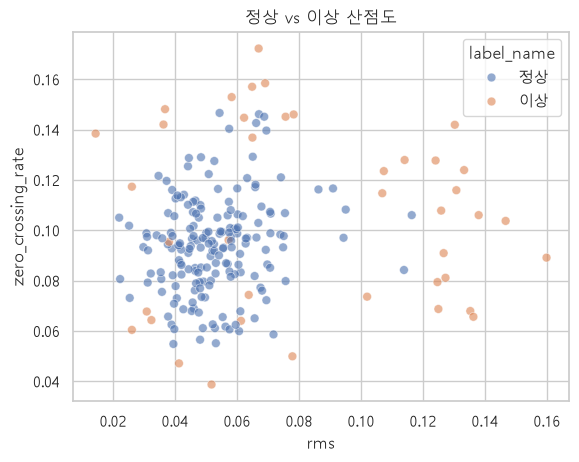

In [ ]:
# 색 구분 산점도
sns.scatterplot(data=df, x="rms", y="zero_crossing_rate",
                hue="label_name", alpha=0.6, s=40)
plt.title("정상 vs 이상 산점도")
plt.show()

0.135


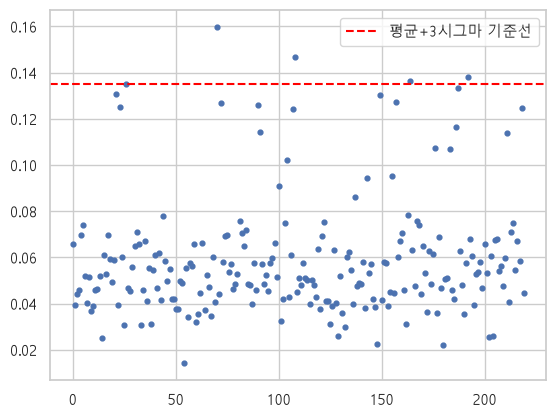

In [ ]:
# 평균+3σ 기준선
thr = df["rms"].mean() + 3 * df["rms"].std()
print(round(thr, 3))
# 출력: 0.134   (rms 평균+3σ 기준값)
plt.scatter(range(len(df)), df["rms"], s=12)
plt.axhline(y=thr, color="red", linestyle="--", label="평균+3시그마 기준선")
plt.legend()
plt.show()

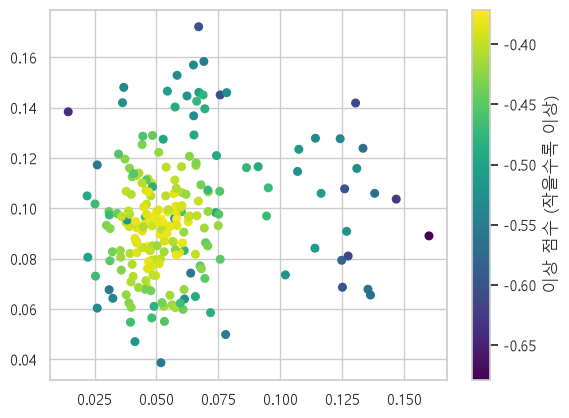

In [ ]:
# 이상 점수를 색 농담으로
sc = plt.scatter(df["rms"], df["zero_crossing_rate"], c=df["score"], cmap="viridis", s=30)
plt.colorbar(sc, label="이상 점수 (작을수록 이상)")
plt.show()

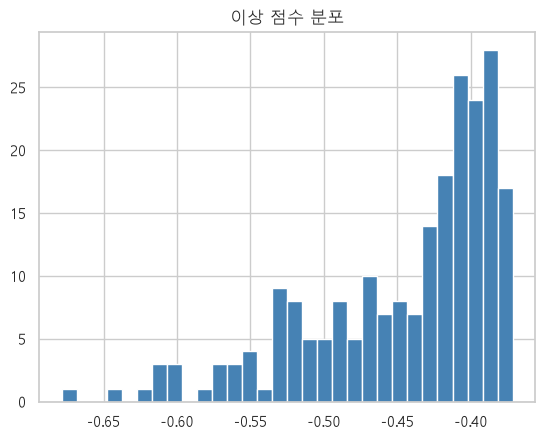

In [ ]:
# 이상 점수 히스토그램
plt.hist(df["score"], bins=30, color="steelblue", edgecolor="white")
plt.title("이상 점수 분포")
plt.show()

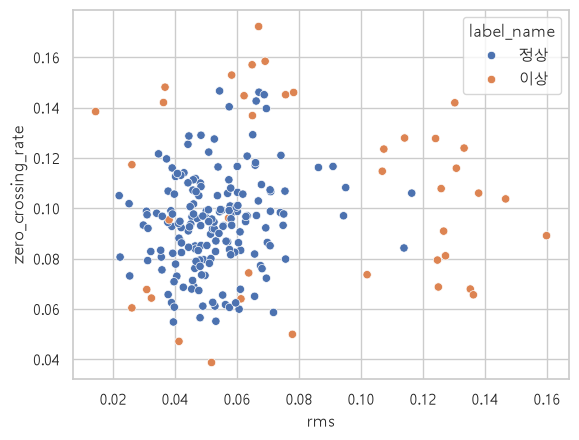

In [ ]:
# 그림 저장(savefig를 show보다 먼저)
sns.scatterplot(data=df, x="rms", y="zero_crossing_rate", hue="label_name")
plt.savefig("anomaly_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# 실습

In [ ]:
# 실습 1 — 이상 라벨 만들고 붙이기
iso = IsolationForest(contamination=0.18, random_state=42)
pred = iso.fit_predict(df[feats])
df["anomaly"] = (pred == -1).astype(int)             # -1(이상)→1
df["label_name"] = df["anomaly"].map({1: "이상", 0: "정상"})
df["score"] = iso.score_samples(df[feats])
print(int(df["anomaly"].sum()))                      # 40
print(df[feats + ["anomaly", "label_name", "score"]].head())

40
      rms  spectral_centroid  zero_crossing_rate  anomaly label_name     score
0  0.0659             1982.7              0.1171        0         정상 -0.416981
1  0.0393             2160.8              0.0821        0         정상 -0.407007
2  0.0443             2065.9              0.0910        0         정상 -0.384584
3  0.0458             1884.4              0.1072        0         정상 -0.392573
4  0.0698             2430.9              0.0864        0         정상 -0.442455


In [ ]:
# 실습 2 — 이상 샘플 추출하기
anom_df = df[df["anomaly"] == 1].sort_values("score")  # 점수 작은 순
print(len(anom_df))                                    # 40
print(anom_df[feats + ["score"]].head(5))              # 가장 이상한 5개

40
        rms  spectral_centroid  zero_crossing_rate     score
70   0.1599             1947.0              0.0891 -0.678462
54   0.0144             1864.1              0.1384 -0.638786
108  0.1467             2674.4              0.1037 -0.625262
157  0.1273             1577.0              0.0811 -0.613582
149  0.1303             2126.7              0.1419 -0.610869


In [ ]:
# 실습 3 — 정답과 교차표 만들기
ct = pd.crosstab(df["label"], df["anomaly"])
print(ct)
hit = int(ct.loc[1, 1])
fp = int(ct.loc[0, 1])
miss = int(ct.loc[1, 0])
print("맞힘", hit, "거짓경보", fp, "놓침", miss)

anomaly    0   1
label           
0        166  14
1         14  26
맞힘 26 거짓경보 14 놓침 14


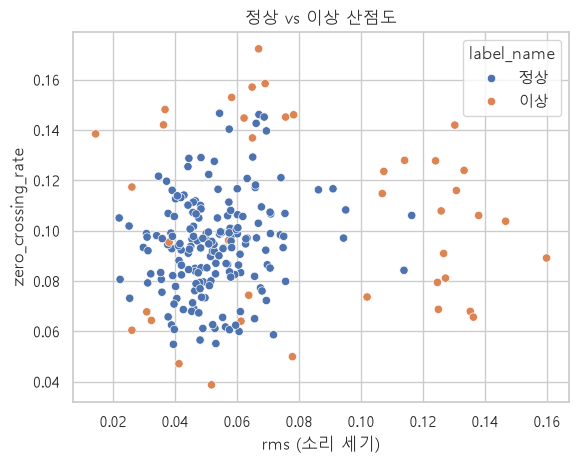

In [ ]:
# 실습 4 — 정상·이상 산점도 그리기
sns.scatterplot(data=df, x="rms", y="zero_crossing_rate", hue="label_name")
plt.title("정상 vs 이상 산점도")
plt.xlabel("rms (소리 세기)")
plt.show()